<a href="https://colab.research.google.com/github/AdhvikaECE536/AdhvikaECE536/blob/main/grp57.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

#LOAD DATA

In [20]:

df = pd.read_excel('AirQualityUCI.xlsx')
print("DATASET LOADED")
print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn names:")
print(list(df.columns))
print("\nFirst 3 rows:")
print(df.head())

DATASET LOADED
Shape: (9357, 15)  →  9357 rows, 15 columns

Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

First 3 rows:
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25 

#ERROR CODE VALUES: -200


In [21]:
df.replace(-200, np.nan, inplace=True)

# Fill NaN with 0
df.fillna(0, inplace=True)

print("Done. All -200 values are now 0.")

Done. All -200 values are now 0.


#DATA VALIDITY REPORT

In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
total_rows = len(df)

validity_data = []
for col in numeric_cols:
    zero_count   = (df[col] == 0).sum()
    valid_count  = total_rows - zero_count
    zero_pct     = (zero_count / total_rows) * 100
    valid_pct    = 100 - zero_pct
    validity_data.append({
        'Column': col,
        'Total Rows': total_rows,
        'Valid (non-zero)': valid_count,
        'Zero Count': zero_count,
        '% Valid': round(valid_pct, 2),
        '% Zero': round(zero_pct, 2)
    })

validity_df = pd.DataFrame(validity_data)
print(validity_df.to_string(index=False))

# Flag columns with more than 50% zeros — these are unreliable
bad_cols = validity_df[validity_df['% Zero'] > 50]['Column'].tolist()
print(f"\n⚠ Columns with >50% zero values (unreliable): {bad_cols}")
print("→ We will DROP these columns before training.")

       Column  Total Rows  Valid (non-zero)  Zero Count  % Valid  % Zero
       CO(GT)        9357              7674        1683    82.01   17.99
  PT08.S1(CO)        9357              8991         366    96.09    3.91
     NMHC(GT)        9357               914        8443     9.77   90.23
     C6H6(GT)        9357              8991         366    96.09    3.91
PT08.S2(NMHC)        9357              8991         366    96.09    3.91
      NOx(GT)        9357              7718        1639    82.48   17.52
 PT08.S3(NOx)        9357              8991         366    96.09    3.91
      NO2(GT)        9357              7715        1642    82.45   17.55
 PT08.S4(NO2)        9357              8991         366    96.09    3.91
  PT08.S5(O3)        9357              8991         366    96.09    3.91
            T        9357              8991         366    96.09    3.91
           RH        9357              8991         366    96.09    3.91
           AH        9357              8991        

#HANDLING MISSING VALUES

In [23]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness per column (positive = right-skewed, higher = more skewed):")
print(skewness.round(2))

print("""
INTERPRETATION:
  • Skewness near 0    → symmetric, mean ≈ median (safe to use either)
  • Skewness > 1       → right-skewed, mean is pulled UP by high spikes
  • Skewness < -1      → left-skewed, mean is pulled DOWN

  For right-skewed data, MEDIAN is the correct fill value.
  It represents a "typical" reading without being distorted by spikes.
""")

# Show a quick comparison: mean vs median for CO(GT)
co_mean   = df['CO(GT)'].mean()
co_median = df['CO(GT)'].median()
print(f"CO(GT) example → Mean: {co_mean:.3f}  |  Median: {co_median:.3f}")
print("The median is lower and more representative of a typical hour.")

# Re-fill zeros with median of non-zero values for better model accuracy
print("\nRe-filling zeros with column median (non-zero median):")
sensor_cols = [c for c in numeric_cols if c not in ['NMHC(GT)']]
for col in sensor_cols:
    non_zero_median = df[col][df[col] != 0].median()
    count_replaced  = (df[col] == 0).sum()
    if count_replaced > 0:
        df[col] = df[col].replace(0, non_zero_median)
        print(f"  {col}: replaced {count_replaced} zeros with median = {non_zero_median:.3f}")

Skewness per column (positive = right-skewed, higher = more skewed):
NMHC(GT)         5.89
NOx(GT)          1.72
C6H6(GT)         1.32
CO(GT)           1.20
PT08.S5(O3)      0.23
T                0.19
NO2(GT)          0.16
PT08.S3(NOx)     0.15
AH              -0.03
PT08.S2(NMHC)   -0.34
RH              -0.36
PT08.S4(NO2)    -0.92
PT08.S1(CO)     -1.20
dtype: float64

INTERPRETATION:
  • Skewness near 0    → symmetric, mean ≈ median (safe to use either)
  • Skewness > 1       → right-skewed, mean is pulled UP by high spikes
  • Skewness < -1      → left-skewed, mean is pulled DOWN

  For right-skewed data, MEDIAN is the correct fill value.
  It represents a "typical" reading without being distorted by spikes.

CO(GT) example → Mean: 1.766  |  Median: 1.500
The median is lower and more representative of a typical hour.

Re-filling zeros with column median (non-zero median):
  CO(GT): replaced 1683 zeros with median = 1.800
  PT08.S1(CO): replaced 366 zeros with median = 1063.000
  C6H6(

#DROPPING UNRELIABLE COLUMNS

In [ ]:
if 'NMHC(GT)' in df.columns:
    df.drop(columns=['NMHC(GT)'], inplace=True)
    print("Dropped: NMHC(GT)  (>90% was sensor-failure data)")

Dropped: NMHC(GT)  (>90% was sensor-failure data)


#EXTRACT FEATURES: USING PARSING

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'].astype(str), errors='coerce')

df['Hour']      = df['Time'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month']     = df['Date'].dt.month

print("Extracted: Hour, DayOfWeek, Month")
print(f"  Hour range     : {df['Hour'].min()} to {df['Hour'].max()}")
print(f"  Months covered : {sorted(df['Month'].unique())}")

df.drop(columns=['Date', 'Time'], inplace=True)
print("Dropped raw Date and Time columns (non-numeric, already extracted)")

Extracted: Hour, DayOfWeek, Month
  Hour range     : 0 to 23
  Months covered : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Dropped raw Date and Time columns (non-numeric, already extracted)


#CREATE AQI TARGET LABELS FROM CO(GT)

In [ ]:
def get_aqi_label(co):
    if co < 2:    return 'Good'
    elif co < 5:  return 'Moderate'
    elif co < 10: return 'Unhealthy'
    else:         return 'Hazardous'

df['AQI_Class'] = df['CO(GT)'].apply(get_aqi_label)

print("AQI class distribution:")
dist = df['AQI_Class'].value_counts()
for label, count in dist.items():
    pct = count / len(df) * 100
    print(f"  {label:12s}: {count:5d} rows  ({pct:.1f}%)")

le = LabelEncoder()
df['AQI_Label'] = le.fit_transform(df['AQI_Class'])
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

AQI class distribution:
  Good        :  5808 rows  (62.1%)
  Moderate    :  3167 rows  (33.8%)
  Unhealthy   :   377 rows  (4.0%)
  Hazardous   :     5 rows  (0.1%)

Encoding: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3)}


#FEATURE SCALING & TRAIN/TEST SPLIT

In [ ]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ['AQI_Label']]
X = df[feature_cols]
y = df['AQI_Label']

print(f"Features used ({len(feature_cols)}): {feature_cols}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Features used (15): ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'DayOfWeek', 'Month']
Train: 7485 rows  |  Test: 1872 rows


#TRAIN & COMPARE 5 MODELS

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'AdaBoost':      AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'SVM':           SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Naive Bayes':   GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    cv  = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'F1 Macro': f1, 'CV Score': cv,
                     'model': model, 'y_pred': y_pred}
    print(f"{name:20s} → Accuracy: {acc:.4f}  F1: {f1:.4f}  CV: {cv:.4f}")

print("\nSummary (sorted by Accuracy):")
summary = pd.DataFrame({k: {m: v for m, v in v.items() if m not in ['model', 'y_pred']}
                         for k, v in results.items()}).T
print(summary.sort_values('Accuracy', ascending=False).round(4))

Random Forest        → Accuracy: 0.9989  F1: 0.8719  CV: 0.9982
AdaBoost             → Accuracy: 0.9557  F1: 0.4844  CV: 0.9599
SVM                  → Accuracy: 0.9781  F1: 0.8391  CV: 0.9480
KNN                  → Accuracy: 0.9322  F1: 0.8015  CV: 0.8366
Naive Bayes          → Accuracy: 0.8729  F1: 0.7795  CV: 0.8603

Summary (sorted by Accuracy):
               Accuracy  F1 Macro  CV Score
Random Forest    0.9989    0.8719    0.9982
SVM              0.9781    0.8391    0.9480
AdaBoost         0.9557    0.4844    0.9599
KNN              0.9322    0.8015    0.8366
Naive Bayes      0.8729    0.7795    0.8603


#HYPERPARAMETER TUNING

In [ ]:
param_dist = {
    'n_estimators':      [50, 100, 150, 200],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

# n_iter=10  → only 10 random combos tried (was 18 before)
# cv=3       → 3 folds instead of 5 (was 5 before)
# Together: 10 × 3 = 30 fits total  vs  90 fits before → 3x faster
rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1          # prints progress so you know it's running
)
rand_search.fit(X_train, y_train)

print("\nBest parameters:", rand_search.best_params_)
print("Best CV F1 score:", round(rand_search.best_score_, 4))

best_rf     = rand_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("\nTuned Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Best CV F1 score: 0.9134

Tuned Random Forest — Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      1166
   Hazardous       0.50      0.50      0.50         2
    Moderate       1.00      1.00      1.00       623
   Unhealthy       0.99      0.99      0.99        81

    accuracy                           1.00      1872
   macro avg       0.87      0.87      0.87      1872
weighted avg       1.00      1.00      1.00      1872



#VISUALIZATIONS

In [ ]:
names  = list(results.keys())
accs   = [results[n]['Accuracy'] for n in names]
colors = ['#185FA5' if n == 'Random Forest' else '#B5D4F4' for n in names]

fig, axes = plt.subplots(5, 1, figsize=(10, 40))
fig.suptitle('Air Quality Index — Analysis Report',
             fontsize=16, fontweight='bold', y=1.002)

# 1. CO(GT) distribution — why median over mean
ax1 = axes[0]
co_vals = df['CO(GT)'][df['CO(GT)'] > 0]
ax1.hist(co_vals, bins=50, color='#378ADD', edgecolor='white', alpha=0.85)
ax1.axvline(co_vals.mean(),   color='#E24B4A', linewidth=2, label=f'Mean = {co_vals.mean():.2f}')
ax1.axvline(co_vals.median(), color='#27500A', linewidth=2, label=f'Median = {co_vals.median():.2f}')
ax1.set_xlabel('CO(GT) value (mg/m³)')
ax1.set_ylabel('Frequency')
ax1.set_title('CO(GT) Distribution — Right-Skewed (why we use median, not mean)')
ax1.legend(fontsize=10)

# 2. AQI class distribution
ax2 = axes[1]
class_colors = {'Good': '#27500A', 'Moderate': '#BA7517',
                'Unhealthy': '#993C1D', 'Hazardous': '#A32D2D'}
aqi_counts = df['AQI_Class'].value_counts()
bars = ax2.bar(aqi_counts.index, aqi_counts.values,
               color=[class_colors[c] for c in aqi_counts.index], edgecolor='white')
ax2.set_title('AQI Class Distribution — Is the dataset balanced?')
ax2.set_ylabel('Count')
for bar, (label, val) in zip(bars, aqi_counts.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontsize=10)

# 3. Model accuracy comparison
ax3 = axes[2]
bars3 = ax3.bar(names, accs, color=colors, edgecolor='white')
ax3.set_ylim(0.5, 1.05)
ax3.set_title('Test Accuracy by Model — Random Forest wins')
ax3.set_ylabel('Accuracy')
for bar, val in zip(bars3, accs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=10)

# 4. Confusion matrix
ax4 = axes[3]
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax4.set_title('Confusion Matrix — Tuned Random Forest')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')

# 5. Feature importances
ax5 = axes[4]
fi = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi.tail(10).plot(kind='barh', ax=ax5, color='#378ADD')
ax5.set_title('Top Feature Importances — Which sensors actually matter?')
ax5.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('aqi_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as aqi_report.png")

# 6. Average CO by hour of day
ax6 = axes[10]
hourly = df.groupby('Hour')['CO(GT)'].mean()
ax6.plot(hourly.index, hourly.values, color='#185FA5', linewidth=2,
          marker='o', markersize=4)
ax6.fill_between(hourly.index, hourly.values, alpha=0.2, color='#185FA5')
ax6.set_title('Avg CO by Hour of Day (Rush-hour peaks visible)')
ax6.set_xlabel('Hour')
ax6.set_ylabel('Avg CO(GT)')

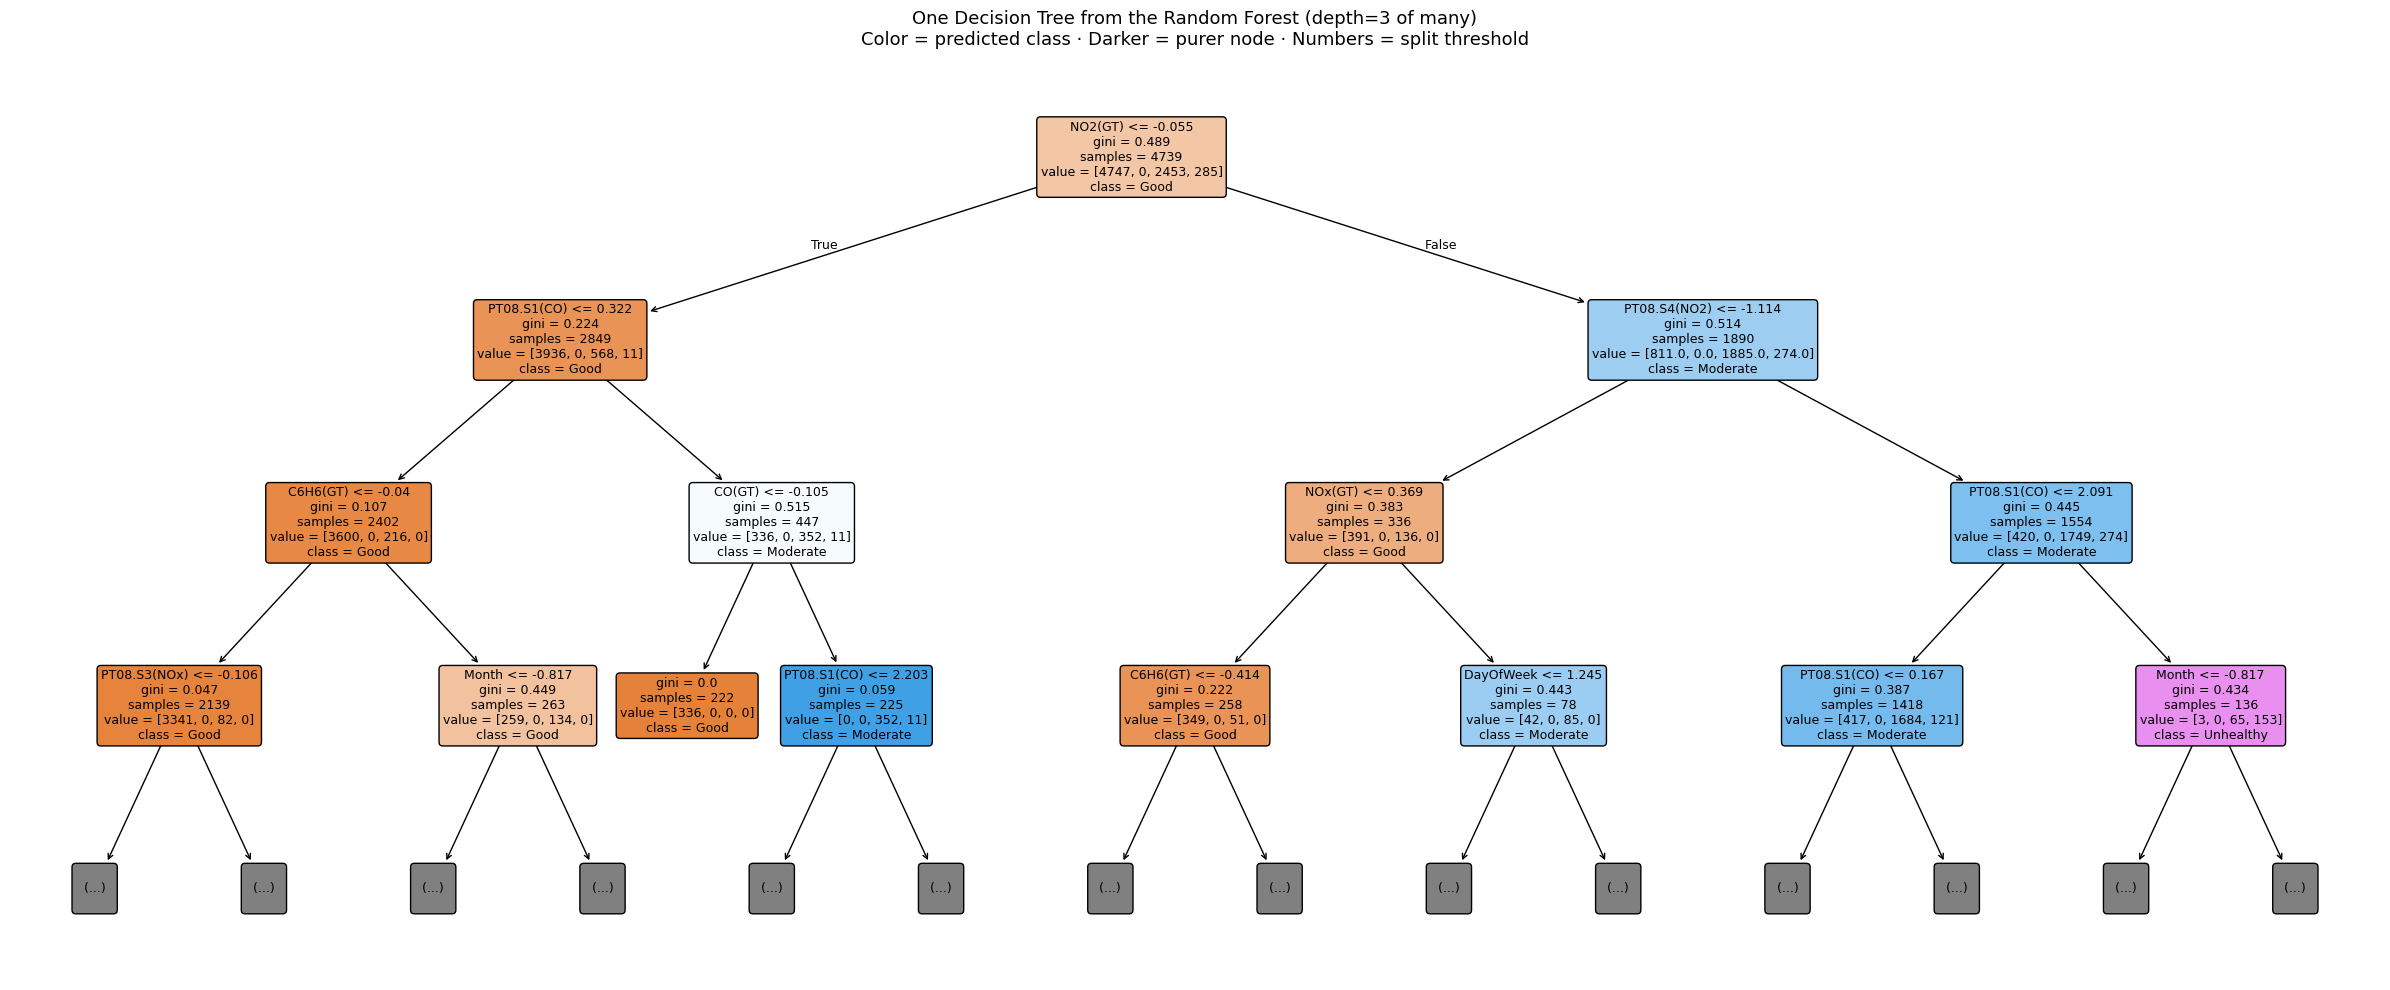

Tree plot saved as random_forest_tree.png


In [ ]:
from sklearn.tree import export_graphviz, plot_tree


fig_tree, ax_tree = plt.subplots(figsize=(24, 10))

plot_tree(
    best_rf.estimators_[0],   # pull the first tree out of the forest
    max_depth=3,              # only show 3 levels — deeper = unreadable
    feature_names=feature_cols,
    class_names=le.classes_,
    filled=True,              # color nodes by majority class
    rounded=True,
    fontsize=9,
    ax=ax_tree
)

ax_tree.set_title(
    'One Decision Tree from the Random Forest (depth=3 of many)\n'
    'Color = predicted class · Darker = purer node · Numbers = split threshold',
    fontsize=13, pad=15
)

plt.tight_layout()
plt.savefig('random_forest_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree plot saved as random_forest_tree.png")
